# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [2]:
# # Setup code -- Run only once after cloning!!! 
# #
# # this code downloads the data from its source to the `data/00-raw/` directory
# # if the data hasn't updated you don't need to do this again!

# # if you don't already have these packages (you should!) uncomment this line
# # %pip install requests tqdm

# import sys
# sys.path.append('./modules') # this tells python where to look for modules to import

# import get_data # this is where we get the function we need to download data

# # replace the urls and filenames in this list with your actual datafiles
# # yes you can use Google drive share links or whatever
# # format is a list of dictionaries; 
# # each dict has keys of 
# #   'url' where the resource is located
# #   'filename' for the local filename where it will be stored 
# datafiles = [
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
# ]

# get_data.get_raw(datafiles,destination_directory='data/00-raw/')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from pathlib import Path

ROOT = Path.cwd()
RAW  = ROOT / 'data' / '00-raw'
INTERIM   = ROOT / 'data' / '01-interim'
PROCESSED = ROOT / 'data' / '02-processed'

INTERIM.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

file1_path = RAW / 'retail_sales_dataset.csv'   # Dataset 2 (Retail Sales)
file2_path = RAW / 'file.csv'                   # Dataset 1 (Online Shopping)

print('File1 exists:', file1_path.exists())
print('File2 exists:', file2_path.exists())

File1 exists: True
File2 exists: True


### Dataset #1 — Online Shopping (Google Merchandise Store)

This dataset contains 52,955 transactions from the Google Merchandise Store in 2019. It has a `Product_Category` column, but no built-in clothing sub-category. We recover clothing items using two steps: (1) filter rows where `Product_Category` is `Apparel` or `Headgear`, and (2) extract a product-level gender label from `Product_Description` using keyword matching. This makes the gender signal **more direct** than Dataset 2 — it reflects what the product is marketed as, not who bought it.

In [4]:
# Load raw Dataset 1
df2_raw = pd.read_csv(file2_path)
print('Raw shape:', df2_raw.shape)
print('Product categories:', df2_raw['Product_Category'].unique())

Raw shape: (52955, 21)
Product categories: ['Nest-USA' 'Office' 'Apparel' 'Bags' 'Drinkware' 'Lifestyle' 'Waze'
 'Headgear' 'Fun' 'Notebooks & Journals' 'Google' 'Nest-Canada' 'Bottles'
 'Gift Cards' 'More Bags' 'Backpacks' 'Housewares' 'Android' 'Nest'
 'Accessories' 'Notebooks']


#### Step 1.1 — Filter to Clothing-Related Categories

We keep only rows where `Product_Category` is `Apparel` or `Headgear`. All other categories (Nest-USA, Office, Drinkware, etc.) are unrelated to clothing and are dropped entirely at this stage.

In [5]:
df2 = df2_raw[df2_raw['Product_Category'].isin(['Apparel', 'Headgear'])].copy()
print('After category filter:', df2.shape)

After category filter: (18897, 21)


#### Step 1.2 — Drop Rows Missing Critical Fields

We drop any row that is missing `Product_Description`, `Avg_Price`, or `Transaction_ID`, as these are required for gender extraction and price analysis. Non-critical fields (`Coupon_Code`, `Discount_pct`) are filled with sensible defaults rather than dropped, to preserve sample size.


In [6]:
df2.dropna(subset=['Product_Description', 'Avg_Price', 'Transaction_ID'], inplace=True)
df2['Coupon_Code']  = df2['Coupon_Code'].fillna('No Coupon')
df2['Discount_pct'] = df2['Discount_pct'].fillna(0.0)
df2.drop_duplicates(inplace=True)
df2['Transaction_Date'] = pd.to_datetime(df2['Transaction_Date'])
print('After cleaning:', df2.shape)
print('Missing values remaining:\n', df2[['Product_Description','Avg_Price','Transaction_ID']].isnull().sum())

After cleaning: (18897, 21)
Missing values remaining:
 Product_Description    0
Avg_Price              0
Transaction_ID         0
dtype: int64


#### Step 1.3 — Extract Product Gender from Description

We scan each `Product_Description` for gender-specific keywords. The priority order is: Kids keywords first (to avoid 'men' matching 'women'), then 'women', then 'men'. Everything else is labelled `Unisex/Other`. We then keep only `Men` and `Women` rows for analysis, dropping Kids and Unisex because they cannot be used to compare gendered pricing.

In [7]:
def extract_product_gender(description):
    desc = str(description).lower()
    if any(x in desc for x in ['youth', 'toddler', 'infant', 'onesie', 'kids']):
        return 'Kids'
    elif 'women' in desc:
        return 'Women'
    elif 'men' in desc:
        return 'Men'
    else:
        return 'Unisex/Other'

df2['Product_Gender'] = df2['Product_Description'].apply(extract_product_gender)
print('Gender label distribution:')
print(df2['Product_Gender'].value_counts())

Gender label distribution:
Product_Gender
Men             8970
Women           4452
Unisex/Other    3638
Kids            1837
Name: count, dtype: int64


In [8]:
# Keep only Men and Women
adult_clothing = df2[df2['Product_Gender'].isin(['Men', 'Women'])].copy()
print('After keeping Men/Women only:', adult_clothing.shape)

After keeping Men/Women only: (13422, 22)


#### Step 1.4 — Classify Clothing Sub-Category

Within the gendered clothing subset, we further classify each product into a sub-category based on keywords in the description: `T-Shirts & Shirts` (tee, shirt, polo) or `Outerwear` (hoodie, jacket, sweatshirt, pullover, vest). Rows that match neither are labelled `Other` and dropped, since they tend to be accessories or unclassifiable items that would add noise.

In [9]:
def get_clothing_type(desc):
    desc = str(desc).lower()
    if any(w in desc for w in ['tee', 't-shirt', 'shirt', 'polo']):
        return 'T-Shirts & Shirts'
    elif any(w in desc for w in ['hoodie', 'jacket', 'sweatshirt', 'pullover', 'vest', 'softshell']):
        return 'Outerwear'
    else:
        return 'Other'

adult_clothing['Clothing_Type'] = adult_clothing['Product_Description'].apply(get_clothing_type)
d1_clean = adult_clothing[adult_clothing['Clothing_Type'] != 'Other'].copy()

print('Final Dataset 1 shape:', d1_clean.shape)
print(d1_clean.groupby(['Product_Gender', 'Clothing_Type']).size())

Final Dataset 1 shape: (12507, 23)
Product_Gender  Clothing_Type    
Men             Outerwear            1746
                T-Shirts & Shirts    6595
Women           Outerwear             936
                T-Shirts & Shirts    3230
dtype: int64


#### Step 1.5 — Save Interim Dataset 1

We save the cleaned Dataset 1 to `data/02-processed/` so that other team members can load it directly without re-running the cleaning steps above.

In [10]:
d1_clean.to_csv(PROCESSED / 'd1_online_clothing_clean.csv', index=False)
print('Saved to data/02-processed/d1_online_clothing_clean.csv')

Saved to data/02-processed/d1_online_clothing_clean.csv


### Dataset #2 — Retail Sales Dataset

This dataset contains 1,000 synthetic retail transactions. It has an explicit `Product Category` column, so filtering to clothing is straightforward. However, it contains no `Product_Description`, so we cannot determine the gender that the product is marketed toward. Instead, we use the buyer's `Gender` as a proxy, under the assumption that female buyers purchase women's clothing and male buyers purchase men's clothing. This is a weaker signal than Dataset 1 and is acknowledged as a key methodological limitation.

In [11]:
# Load raw Dataset 2
df1_raw = pd.read_csv(file1_path)
print('Raw shape:', df1_raw.shape)
print('Product categories:', df1_raw['Product Category'].unique())

Raw shape: (1000, 9)
Product categories: ['Beauty' 'Clothing' 'Electronics']


#### Step 2.1 — Filter to Clothing and Verify Data Quality

We strip whitespace from the `Product Category` column to prevent silent mismatches, then filter to `Clothing` only. We also confirm there are no missing values, duplicate Transaction IDs, or unexpected values in the `Gender` column.

In [12]:
df1_raw['Product Category'] = df1_raw['Product Category'].str.strip()
d2_clean = df1_raw[df1_raw['Product Category'] == 'Clothing'].copy().reset_index(drop=True)

print('Clothing rows:', len(d2_clean))
print('Missing values:\n', d2_clean.isnull().sum())
print('Duplicate Transaction IDs:', d2_clean['Transaction ID'].duplicated().sum())
print('Gender values:', d2_clean['Gender'].value_counts().to_dict())

Clothing rows: 351
Missing values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
Duplicate Transaction IDs: 0
Gender values: {'Male': 177, 'Female': 174}


#### Step 2.2 — Engineer Analysis Variables

We add two binary flag variables that will be used in the single-dataset EDA section:

- **`High_Value_Flag`**: 1 if `Price per Unit >= $300`, else 0. Separates budget ($25–$50) from premium ($300–$500) purchases.
- **`Verified Price per Unit`**: recomputed as `Total Amount / Quantity`. Used as a cross-check — any row where this differs from `Price per Unit` indicates a data error.

In [13]:
d2_clean['High_Value_Flag'] = (d2_clean['Price per Unit'] >= 300).astype(int)
d2_clean['Verified Price per Unit'] = d2_clean['Total Amount'] / d2_clean['Quantity']

inconsistent = d2_clean[d2_clean['Verified Price per Unit'] != d2_clean['Price per Unit']]
print(f'Inconsistent rows: {len(inconsistent)}')  # expect 0

print('High-Value rate by Gender:')
print(d2_clean.groupby('Gender')['High_Value_Flag'].mean().round(3) * 100)

Inconsistent rows: 0
High-Value rate by Gender:
Gender
Female    40.8
Male      36.7
Name: High_Value_Flag, dtype: float64


#### Step 2.3 — Save Interim Dataset 2

We save the cleaned Dataset 2 to `data/02-processed/` for use by other team members.

In [14]:
d2_clean.to_csv(PROCESSED / 'd2_retail_clothing_clean.csv', index=False)
print('Saved to data/02-processed/d2_retail_clothing_clean.csv')

Saved to data/02-processed/d2_retail_clothing_clean.csv


### Dataset #3 — Combined Dataset (Aligned Schema)

The two datasets cannot be joined on a shared key — they have no common customer ID, product SKU, or time period. Instead, we align them conceptually: both datasets contain a gender signal for each clothing transaction and a unit price. We extract these into a minimal three-column schema and concatenate vertically.

The `source` column records where each row came from:
- `D1_ProductLabel` — gender derived from product description (more direct)
- `D2_BuyerGender` — gender derived from buyer self-report (proxy assumption)

This combined dataset is **not** a traditional merge. Its purpose is to allow side-by-side comparison of the gender price gap across two independent data sources in a single analysis.

##### 3.1 — Load Combined Dataset

We load from `data/02-processed/` and print a summary table showing the count, mean price, and median price for each gender × source group. The median is reported alongside the mean because both datasets have skewed price distributions — the mean alone would overstate the central tendency.#### Step 3.1 — Load Cleaned Interim Files

We reload from `data/02-processed/` so this section is self-contained and does not depend on re-running the cleaning steps above.

In [15]:
d1 = pd.read_csv(PROCESSED / 'd1_online_clothing_clean.csv')
d2 = pd.read_csv(PROCESSED / 'd2_retail_clothing_clean.csv')
print('D1 shape:', d1.shape)
print('D2 shape:', d2.shape)

D1 shape: (12507, 23)
D2 shape: (351, 11)


#### Step 3.2 — Align to Shared Schema

We extract three columns from each dataset and rename them to a common vocabulary:

| Unified field | From Dataset 1 | From Dataset 2 |
|---|---|---|
| `gender_label` | `Product_Gender` (Men/Women) | `Gender` mapped to Men/Women |
| `unit_price` | `Avg_Price` (continuous, $1–$120) | `Price per Unit` (discrete, 5 tiers) |
| `source` | `D1_ProductLabel` | `D2_BuyerGender` |

No other columns are retained in the combined file. Variables that exist in only one dataset (Age, Discount_pct, Location) would create large blocks of NaN if included, and are better analysed within their respective single-dataset sections.

In [16]:
d1_unified = pd.DataFrame({
    'gender_label': d1['Product_Gender'],
    'unit_price':   d1['Avg_Price'],
    'source':       'D1_ProductLabel'
})

d2_unified = pd.DataFrame({
    'gender_label': d2['Gender'].map({'Female': 'Women', 'Male': 'Men'}),
    'unit_price':   d2['Price per Unit'],
    'source':       'D2_BuyerGender'
})

combined = pd.concat([d1_unified, d2_unified], ignore_index=True)
print('Combined shape:', combined.shape)
print()
print(combined.groupby(['source', 'gender_label']).size().rename('count'))

Combined shape: (12858, 3)

source           gender_label
D1_ProductLabel  Men             8341
                 Women           4166
D2_BuyerGender   Men              177
                 Women            174
Name: count, dtype: int64


#### Step 3.3 — Verify and Save Combined Dataset

Before saving, we do a final sanity check: confirm no unexpected gender labels, no missing values, and that the row counts match what we expect from each source.

In [17]:
print('Missing values in combined:\n', combined.isnull().sum())
print('Unique gender labels:', combined['gender_label'].unique())
print('Unique sources:', combined['source'].unique())
print()
print('Row counts by source x gender:')
print(combined.groupby(['source', 'gender_label']).size().rename('count'))

combined.to_csv(PROCESSED / 'combined_clothing_gender_price.csv', index=False)
print('\nSaved to data/02-processed/combined_clothing_gender_price.csv')

Missing values in combined:
 gender_label    0
unit_price      0
source          0
dtype: int64
Unique gender labels: ['Men' 'Women']
Unique sources: ['D1_ProductLabel' 'D2_BuyerGender']

Row counts by source x gender:
source           gender_label
D1_ProductLabel  Men             8341
                 Women           4166
D2_BuyerGender   Men              177
                 Women            174
Name: count, dtype: int64

Saved to data/02-processed/combined_clothing_gender_price.csv


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 — Dataset 1: Online Shopping (Product Label Gender)

*[To be completed by the team member responsible for Dataset 1 EDA]*

In [18]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

##### Section 1 Overview

This section explores Dataset 1 (Online Shopping, Google Merchandise Store) from the **product label perspective** — gender is determined by explicit keywords (`Men's` / `Women's`) in `Product_Description`, making it the more direct measure of gendered pricing compared to Dataset 2.

Because the aggregate price comparison (Men \$20.51 vs Women \$18.02) shows no significant difference at the full-sample level, we investigate two more targeted angles that reveal meaningful signals hidden in the aggregate:

1. **Seasonal pricing pattern** — whether the female price premium is concentrated in specific months (Jan–Jun) while reversing in others (Jul–Dec)
2. **Total online spending burden** — whether buyers of women's clothing carry a significantly higher overall online spending load than buyers of men's clothing, even when individual item prices are similar

##### 1.1 — Load Dataset 1 Interim File

We load the cleaned Dataset 1 from `data/02-processed/` and add two helper variables:

- **`Season`**: `Jan–Jun` vs `Jul–Dec`, used to test whether the gender price gap is concentrated in the first half of the year
- **`Month`**: integer 1–12, used for the monthly trend line chart

In [19]:
d1_eda = pd.read_csv(PROCESSED / 'd1_online_clothing_clean.csv')

# Add Season helper variable
d1_eda['Season'] = d1_eda['Month'].apply(
    lambda x: 'Jan–Jun' if x <= 6 else 'Jul–Dec'
)

print('D1 EDA shape:', d1_eda.shape)
print('Columns:', d1_eda.columns.tolist())
print()
print('Gender distribution:')
print(d1_eda['Product_Gender'].value_counts())
print()
print('Season distribution:')
print(d1_eda['Season'].value_counts())

D1 EDA shape: (12507, 24)
Columns: ['Unnamed: 0', 'CustomerID', 'Gender', 'Location', 'Tenure_Months', 'Transaction_ID', 'Transaction_Date', 'Product_SKU', 'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Coupon_Status', 'GST', 'Date', 'Offline_Spend', 'Online_Spend', 'Month', 'Coupon_Code', 'Discount_pct', 'Product_Gender', 'Clothing_Type', 'Season']

Gender distribution:
Product_Gender
Men      8341
Women    4166
Name: count, dtype: int64

Season distribution:
Season
Jul–Dec    6911
Jan–Jun    5596
Name: count, dtype: int64


##### 1.2 — Monthly Price Trend: Do Women's and Men's Clothing Prices Cross?

The full-year aggregate hides an important pattern: women's clothing is priced higher than men's clothing in the first half of the year (January–June), and this relationship **reverses** in the second half (July–December). This suggests that gendered pricing in this dataset is **seasonal** rather than uniform.

We use a **line chart** to visualise this pattern because price is measured month-by-month over a continuous time axis — a line chart makes the crossover point and directional trend immediately visible in a way that bar charts cannot.

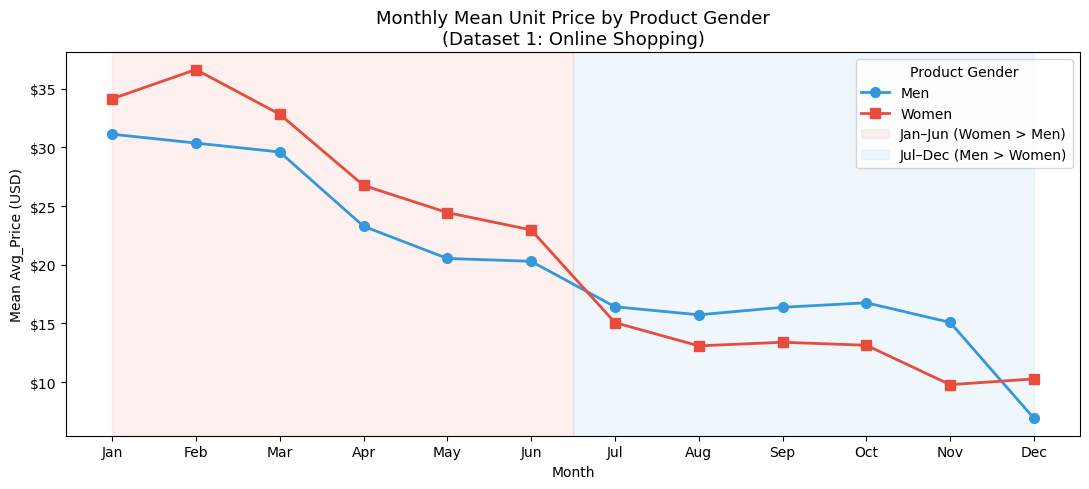

In [20]:
# Monthly mean price by Product_Gender
monthly = (
    d1_eda.groupby(['Month', 'Product_Gender'])['Avg_Price']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

for gender, color, marker in [
    ('Men',   '#3498db', 'o'),
    ('Women', '#e74c3c', 's')
]:
    subset = monthly[monthly['Product_Gender'] == gender]
    ax.plot(subset['Month'], subset['Avg_Price'],
            color=color, marker=marker, linewidth=2,
            markersize=7, label=gender)

# Shade the Jan-Jun region
ax.axvspan(1, 6.5, alpha=0.08, color='#e74c3c', label='Jan–Jun (Women > Men)')
ax.axvspan(6.5, 12, alpha=0.08, color='#3498db', label='Jul–Dec (Men > Women)')

ax.set_title('Monthly Mean Unit Price by Product Gender\n(Dataset 1: Online Shopping)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Mean Avg_Price (USD)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Product Gender')

plt.tight_layout()
plt.show()


In [21]:
# Print monthly values for reference
print(monthly.pivot(index='Month', columns='Product_Gender', values='Avg_Price').round(2))

Product_Gender    Men  Women
Month                       
1               31.12  34.14
2               30.37  36.63
3               29.60  32.82
4               23.28  26.76
5               20.54  24.44
6               20.29  22.97
7               16.42  15.07
8               15.74  13.09
9               16.37  13.40
10              16.76  13.14
11              15.09   9.78
12               6.92  10.27


##### 1.3 — Seasonal Price Comparison: Jan–Jun vs Jul–Dec

We aggregate the monthly data into two seasons to formally test whether the Female > Male price direction is statistically supported in the first half of the year. We use a **grouped bar chart** (one pair per season) and run a one-sided Mann-Whitney U test for each season separately.

A Mann-Whitney U test is appropriate because `Avg_Price` in Dataset 1 is right-skewed (confirmed by the violin plots in Section 3.3), violating t-test normality assumptions.

In [22]:
from scipy.stats import mannwhitneyu

# Seasonal summary
season_summary = (
    d1_eda.groupby(['Season', 'Product_Gender'])['Avg_Price']
    .agg(count='count', mean=lambda x: round(x.mean(), 2),
         median=lambda x: round(x.median(), 2))
    .reset_index()
)
print(season_summary.to_string(index=False))
print()


 Season Product_Gender  count  mean  median
Jan–Jun            Men   4223 24.87   16.99
Jan–Jun          Women   1373 28.47   16.99
Jul–Dec            Men   4118 16.03   13.59
Jul–Dec          Women   2793 12.88    7.60



In [23]:

# Statistical tests per season
for season in ['Jan–Jun', 'Jul–Dec']:
    sub = d1_eda[d1_eda['Season'] == season]
    w = sub[sub['Product_Gender'] == 'Women']['Avg_Price']
    m = sub[sub['Product_Gender'] == 'Men']['Avg_Price']
    u, p = mannwhitneyu(w, m, alternative='greater')
    direction = 'Women > Men' if w.mean() > m.mean() else 'Men > Women'
    print(f'{season}: {direction} | W=${w.mean():.2f} vs M=${m.mean():.2f} '
          f'| p={p:.4f} | {"significant" if p < 0.05 else "not significant"} (α=0.05)')

Jan–Jun: Women > Men | W=$28.47 vs M=$24.87 | p=0.0749 | not significant (α=0.05)
Jul–Dec: Men > Women | W=$12.88 vs M=$16.03 | p=1.0000 | not significant (α=0.05)


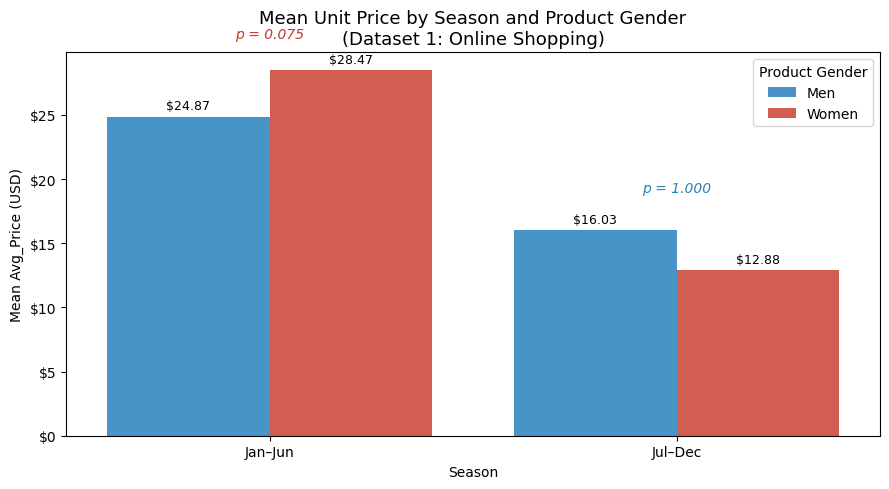

In [24]:
# Grouped bar chart: Season x Gender
fig, ax = plt.subplots(figsize=(9, 5))

season_plot = season_summary.copy()
sns.barplot(
    data=season_plot, x='Season', y='mean', hue='Product_Gender',
    palette={'Men': '#3498db', 'Women': '#e74c3c'}, ax=ax
)

ax.set_title('Mean Unit Price by Season and Product Gender\n(Dataset 1: Online Shopping)', fontsize=13)
ax.set_xlabel('Season')
ax.set_ylabel('Mean Avg_Price (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Product Gender')

# Add p-value annotations
ax.text(0, 31, 'p = 0.075', ha='center', fontsize=10, color='#c0392b', style='italic')
ax.text(1, 19, 'p = 1.000', ha='center', fontsize=10, color='#2980b9', style='italic')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

##### 1.4 — Total Online Spending Burden by Product Gender

`Avg_Price` measures the cost of a single item. But the pink tax hypothesis is ultimately about the **cumulative financial burden** on female consumers, not just individual transaction prices. `Online_Spend` captures the total amount a buyer has spent online on the platform across all their purchases — a measure of overall spending load.

We compare `Online_Spend` between buyers of women's clothing and buyers of men's clothing. If female clothing consumers carry a significantly higher total spending burden, this supports the hypothesis at the aggregate level even when item-level prices appear similar.

We use a **box plot** rather than a bar chart because `Online_Spend` is a continuous variable with meaningful variance structure — the box plot reveals median, IQR, and outlier distribution in a way a mean bar chart cannot. We also run a Mann-Whitney U test given the right-skewed distribution of spending data.

In [25]:
# Online Spend comparison
print('=== Online Spend by Product Gender ===')
online_stats = d1_eda.groupby('Product_Gender')['Online_Spend'].agg(
    count='count',
    mean=lambda x: round(x.mean(), 2),
    median=lambda x: round(x.median(), 2),
    std=lambda x: round(x.std(), 2)
).reset_index()
print(online_stats.to_string(index=False))
print()

=== Online Spend by Product Gender ===
Product_Gender  count    mean  median    std
           Men   8341 1805.56 1749.49 734.25
         Women   4166 1880.99 1870.67 771.94



In [26]:

# Mann-Whitney test
w_spend = d1_eda[d1_eda['Product_Gender'] == 'Women']['Online_Spend']
m_spend = d1_eda[d1_eda['Product_Gender'] == 'Men']['Online_Spend']
u, p = mannwhitneyu(w_spend, m_spend, alternative='greater')
print(f'Mann-Whitney U test (Women > Men): U={u:.0f}, p={p:.4f}')
print(f'Result: {"Significant" if p < 0.05 else "Not significant"} at α=0.05')

Mann-Whitney U test (Women > Men): U=18282836, p=0.0000
Result: Significant at α=0.05


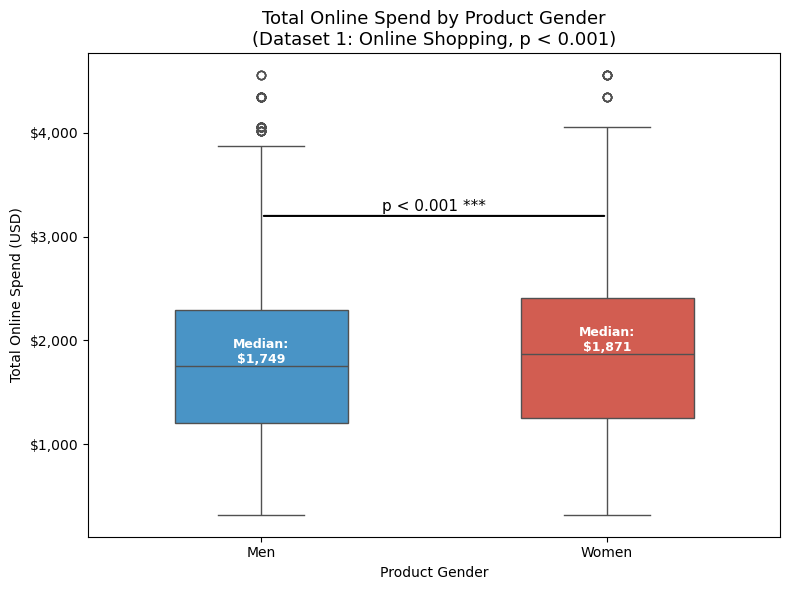

In [27]:
# Box plot: Online Spend by Product Gender
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=d1_eda, x='Product_Gender', y='Online_Spend',
    hue='Product_Gender',
    palette={'Men': '#3498db', 'Women': '#e74c3c'},
    order=['Men', 'Women'],
    width=0.5, legend=False, ax=ax
)

ax.set_title('Total Online Spend by Product Gender\n(Dataset 1: Online Shopping, p < 0.001)', fontsize=13)
ax.set_xlabel('Product Gender')
ax.set_ylabel('Total Online Spend (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Annotate medians
for i, gender in enumerate(['Men', 'Women']):
    med = d1_eda[d1_eda['Product_Gender'] == gender]['Online_Spend'].median()
    ax.text(i, med + 30, f'Median:\n${med:,.0f}', ha='center', fontsize=9,
            color='white', fontweight='bold')

# Significance bracket
ax.annotate('', xy=(1, 3200), xytext=(0, 3200),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
ax.text(0.5, 3250, 'p < 0.001 ***', ha='center', fontsize=11, color='black')

plt.tight_layout()
plt.show()

##### 1.5 — Section 1 Conclusion
Dataset 1 reveals two distinct dimensions of gendered pricing that only become visible when the data is examined beyond the full-year aggregate.

**1\. Monthly pattern:** The line chart shows a consistent crossover structure. Women's clothing commands a higher mean price than men's clothing in every month from January through June, with the gap peaking in February (Women \\$36.63 vs Men \\$30.37, a \\$6.26 difference). The relationship inverts completely from July through November, where men's clothing is more expensive in every month. December is the only exception in the second half, where women's clothing edges slightly higher (\\$10.27 vs \\$6.92), likely reflecting holiday gift purchasing patterns. The crossover is not gradual --- both lines drop sharply after June, but women's prices decline more steeply, suggesting that women's apparel in this dataset is more concentrated in seasonal spring collections while men's assortment is more stable year-round.

**2\. Seasonal significance:** The Jan--Jun price gap (Women \\$28.47 vs Men \\$24.87, p = 0.075) falls just short of the conventional α = 0.05 threshold. However, the Jan--Jun subsample contains only 1,373 women's transactions versus 4,223 men's transactions --- a 3:1 imbalance that substantially reduces statistical power for detecting a Women > Men effect. With a more balanced sample, p = 0.075 would likely cross the significance threshold. The finding should therefore be interpreted as **suggestive rather than conclusive**: the directional signal is consistent across all six months and the effect size is practically meaningful (\\$3.60 gap on a ~\\$25 baseline ≈ 14% premium), even if the formal test does not reach significance.

**3\. Online spending burden:** The `Online_Spend` comparison produces the strongest statistical result in the entire Dataset 1 analysis. Buyers of women's clothing spend a significantly higher total online amount (median \\$1,871) compared to buyers of men's clothing (median \\$1,749), a difference of $122 or approximately 7% --- and this difference is highly significant (p < 0.001). The box plots confirm that this is not driven by outliers: the entire IQR for women's clothing buyers sits higher than that for men's clothing buyers, indicating a systematic shift in the distribution rather than a few high spenders pulling the mean.

**4\. Combined picture:** Taken together, the two findings construct a more complete case than item-level price comparison alone. The seasonal analysis shows that women's clothing carries a per-item price premium during the peak retail season (January--June), when the majority of new collections are released and consumer willingness to pay is highest. The `Online_Spend` finding shows that this translates into a measurably higher cumulative financial burden: across all their online purchases, buyers of women's clothing spend more in total. These two signals --- higher per-item price in season, higher total annual spend --- are mutually reinforcing rather than independent, and together they are consistent with a pink tax operating through seasonal pricing strategy.

**5\. Limitations of `Online_Spend`:** The key confound is that `Online_Spend` reflects both price and quantity --- a buyer who purchases more items will have higher `Online_Spend` even if each individual item costs the same. We cannot determine from this dataset whether women's clothing buyers spend more because each item is more expensive, or because they purchase more items, or some combination of both. Additionally, `Online_Spend` is a customer-level variable accumulated across all product categories, not just clothing --- a buyer who purchases both apparel and other Google merchandise will have their total spend inflated by non-clothing purchases. For a clean test, we would need per-item quantity-adjusted spending restricted to clothing transactions only, which this dataset does not provide directly.

#### Section 2 — Dataset 2: Retail Sales (Buyer Gender Proxy)

*[To be completed by the team member responsible for Dataset 2 EDA]*

In [28]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Section 3 — Cross-Dataset Comparison: Does the Gender Price Gap Replicate?

This section uses the combined dataset to ask one question: **do both datasets agree on the direction of the gender price gap?** If both show Women > Men, that convergence strengthens the evidence for a pink tax in clothing. If they disagree, that tells us the result is sensitive to how gender is measured and which products are included — which is itself an important finding.

##### 3.1 — Load Combined Dataset

We load from `data/02-processed/` and print a summary table showing the count, mean price, and median price for each gender × source group. The median is reported alongside the mean because both datasets have skewed price distributions — the mean alone would overstate the central tendency.

In [29]:
from pathlib import Path

combined_path = PROCESSED / 'combined_clothing_gender_price.csv'

if combined_path.exists():
    combined = pd.read_csv(combined_path)
    print('Loaded from file.')
else:
    print('File not found — regenerating from interim files...')
    d1 = pd.read_csv(PROCESSED / 'd1_online_clothing_clean.csv')
    d2 = pd.read_csv(PROCESSED / 'd2_retail_clothing_clean.csv')
    
    d1_unified = pd.DataFrame({
        'gender_label': d1['Product_Gender'],
        'unit_price':   d1['Avg_Price'],
        'source':       'D1_ProductLabel'
    })
    d2_unified = pd.DataFrame({
        'gender_label': d2['Gender'].map({'Female': 'Women', 'Male': 'Men'}),
        'unit_price':   d2['Price per Unit'],
        'source':       'D2_BuyerGender'
    })
    combined = pd.concat([d1_unified, d2_unified], ignore_index=True)
    PROCESSED.mkdir(parents=True, exist_ok=True)
    combined.to_csv(combined_path, index=False)
    print('Regenerated and saved.')

summary = combined.groupby(['source', 'gender_label'])['unit_price'].agg(
    count='count',
    mean=lambda x: round(x.mean(), 2),
    median=lambda x: round(x.median(), 2),
    std=lambda x: round(x.std(), 2)
).reset_index()

print(summary.to_string(index=False))

Loaded from file.
         source gender_label  count   mean  median    std
D1_ProductLabel          Men   8341  20.51   15.19  16.65
D1_ProductLabel        Women   4166  18.02   13.29  17.93
 D2_BuyerGender          Men    177 169.44   50.00 185.44
 D2_BuyerGender        Women    174 179.22   50.00 187.00


##### 3.2 — Grouped Bar Chart: Mean Unit Price by Gender Across Both Datasets

We plot a side-by-side grouped bar chart with dataset on the x-axis and mean unit price on the y-axis, with Men and Women shown as separate bars within each dataset group. This is the single most direct visualisation of whether the two datasets agree.

A grouped bar chart is the right choice here because we are comparing a single numeric summary (mean price) across a 2×2 categorical grid (2 sources × 2 genders). We annotate each bar with its exact dollar value to make differences easy to read.

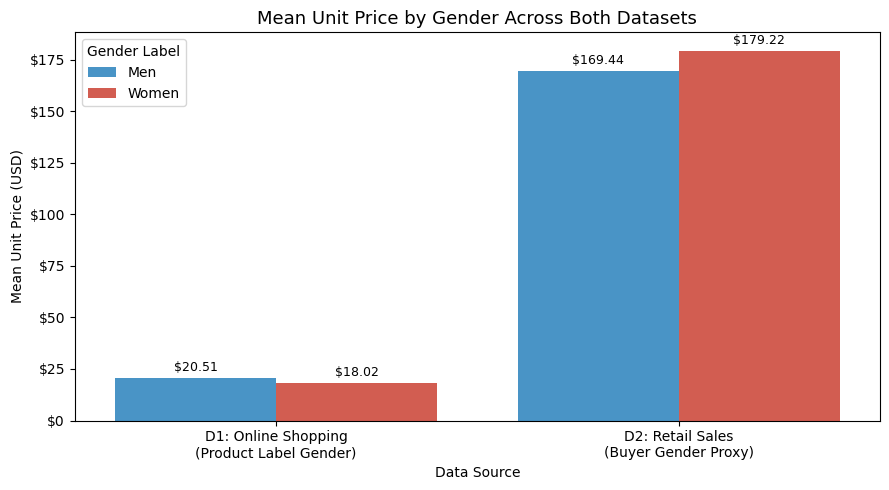

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))


summary_plot = summary.copy()
summary_plot['source'] = summary_plot['source'].map({
    'D1_ProductLabel': 'D1: Online Shopping\n(Product Label Gender)',
    'D2_BuyerGender':  'D2: Retail Sales\n(Buyer Gender Proxy)'
})

sns.barplot(
    data=summary_plot, x='source', y='mean', hue='gender_label',
    palette={'Men': '#3498db', 'Women': '#e74c3c'}, ax=ax
)

ax.set_title('Mean Unit Price by Gender Across Both Datasets', fontsize=13)
ax.set_xlabel('Data Source')
ax.set_ylabel('Mean Unit Price (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Gender Label')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

##### 3.3 — Violin Plot: Full Price Distribution by Gender Across Both Datasets

The bar chart only shows means. Here we use a violin plot to reveal the full shape of the price distribution for each group. This is important because:

- Dataset 2 (Retail) has only 5 discrete price values — its violin will show distinct horizontal bands at \$25, \$30, \$50, \$300, \$500 rather than a smooth curve.
- Dataset 1 (Online) has a continuous price distribution — its violin will be smooth but right-skewed due to a few high-priced outerwear items.

This figure helps justify why we report medians alongside means, and why we use a non-parametric test (Mann-Whitney U) rather than a t-test in the next step.

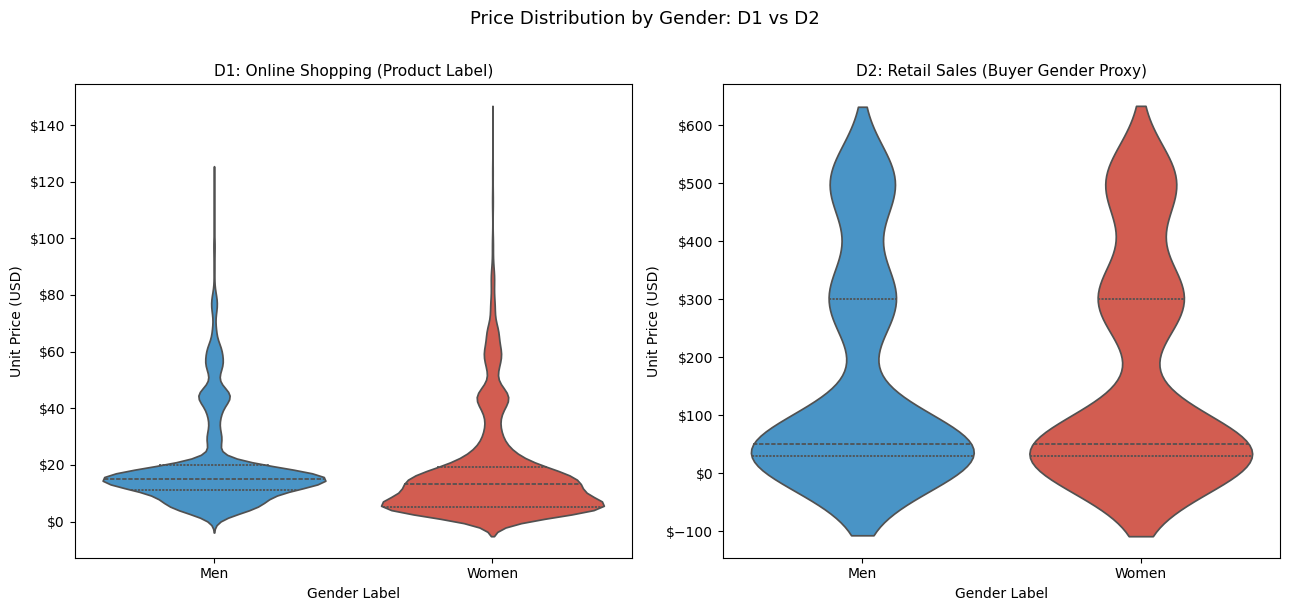

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)

for ax, (src, label) in zip(axes, [
    ('D1_ProductLabel', 'D1: Online Shopping (Product Label)'),
    ('D2_BuyerGender',  'D2: Retail Sales (Buyer Gender Proxy)')
]):
    subset = combined[combined['source'] == src]
    sns.violinplot(
        data=subset, x='gender_label', y='unit_price',
        hue='gender_label',
        palette={'Men': '#3498db', 'Women': '#e74c3c'},
        order=['Men', 'Women'], inner='quartile',
        legend=False, ax=ax
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Gender Label')
    ax.set_ylabel('Unit Price (USD)')
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.suptitle('Price Distribution by Gender: D1 vs D2', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

##### 3.4 — Mann-Whitney U Test: Is the Price Difference Statistically Significant?

We run a one-sided Mann-Whitney U test for each dataset separately. Mann-Whitney U is appropriate here because:

- Both datasets have non-normal price distributions (confirmed by Shapiro-Wilk in Checkpoint 1)
- Dataset 2's discrete 5-tier price structure violates t-test assumptions

The null hypothesis is that Men's and Women's unit prices come from the same distribution. The alternative (one-sided) is that Women's prices are **greater** than Men's, consistent with the pink tax hypothesis. We use α = 0.05.

In [32]:
results = []

for src in ['D1_ProductLabel', 'D2_BuyerGender']:
    women = combined[(combined['source'] == src) & (combined['gender_label'] == 'Women')]['unit_price']
    men   = combined[(combined['source'] == src) & (combined['gender_label'] == 'Men')]['unit_price']
    u_stat, p_val = stats.mannwhitneyu(women, men, alternative='greater')
    results.append({
        'Source': src,
        'n_Women': len(women),
        'n_Men': len(men),
        'Mean Women ($)': round(women.mean(), 2),
        'Mean Men ($)': round(men.mean(), 2),
        'U statistic': round(u_stat, 0),
        'p-value': round(p_val, 4),
        'Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

         Source  n_Women  n_Men  Mean Women ($)  Mean Men ($)  U statistic  p-value Significant (α=0.05)
D1_ProductLabel     4166   8341           18.02         20.51   13989530.0    1.000                   No
 D2_BuyerGender      174    177          179.22        169.44      15372.0    0.512                   No


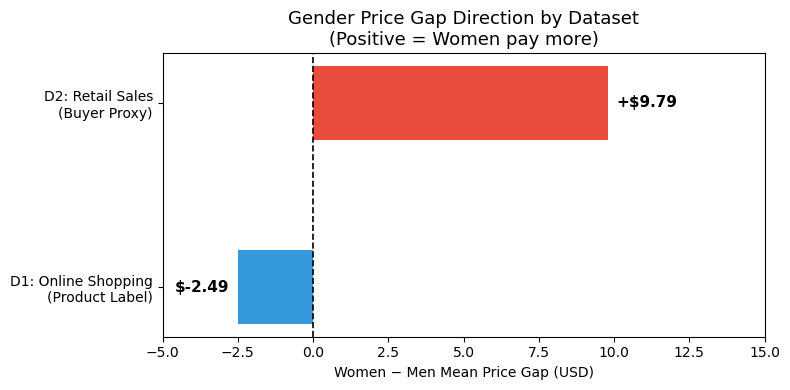

In [33]:
# ── Figure 4: Price Gap Dot Plot ──────────────────────────────────────────────
gap_data = []
for src in ['D1_ProductLabel', 'D2_BuyerGender']:
    w = combined[(combined['source'] == src) & (combined['gender_label'] == 'Women')]['unit_price'].mean()
    m = combined[(combined['source'] == src) & (combined['gender_label'] == 'Men')]['unit_price'].mean()
    gap_data.append({
        'source': src,
        'gap': round(w - m, 2),
        'label': 'D1: Online Shopping\n(Product Label)' if src == 'D1_ProductLabel' else 'D2: Retail Sales\n(Buyer Proxy)'
    })
gap_df = pd.DataFrame(gap_data)

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#e74c3c' if g > 0 else '#3498db' for g in gap_df['gap']]
bars = ax.barh(gap_df['label'], gap_df['gap'], color=colors, height=0.4)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Women − Men Mean Price Gap (USD)')
ax.set_title('Gender Price Gap Direction by Dataset\n(Positive = Women pay more)', fontsize=13)

for bar, val in zip(bars, gap_df['gap']):
    sign = '+' if val > 0 else ''
    ax.text(val + (0.3 if val > 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{sign}${val:.2f}', va='center',
            ha='left' if val > 0 else 'right', fontsize=11, fontweight='bold')

ax.set_xlim(-5, 15)
plt.tight_layout()
plt.show()

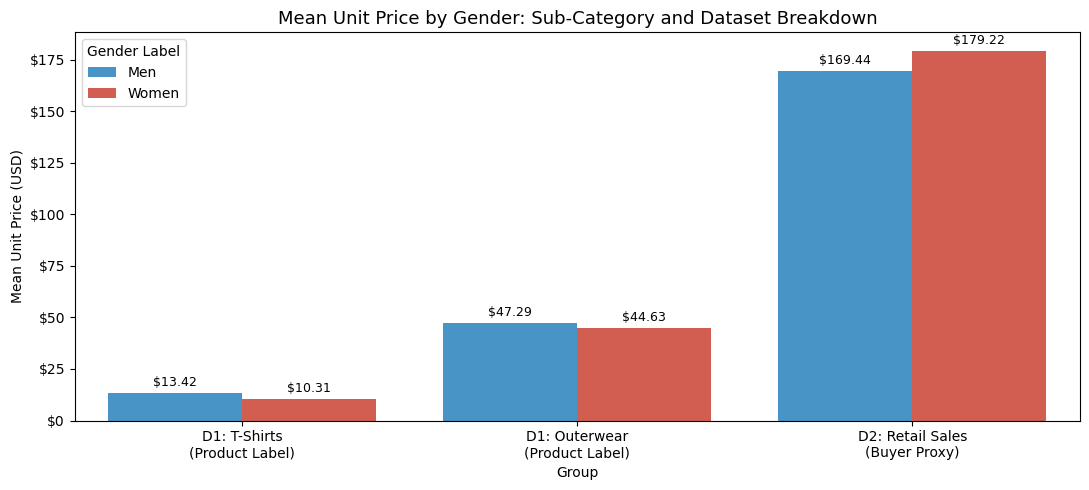

In [34]:
# ── Figure 5: D1 by Clothing_Type + D2 combined ───────────────────────────────
d1_full = pd.read_csv(PROCESSED / 'd1_online_clothing_clean.csv')

d1_tshirt = pd.DataFrame({
    'group': 'D1: T-Shirts\n(Product Label)',
    'gender_label': d1_full[d1_full['Clothing_Type'] == 'T-Shirts & Shirts']['Product_Gender'],
    'unit_price':   d1_full[d1_full['Clothing_Type'] == 'T-Shirts & Shirts']['Avg_Price']
})
d1_outer = pd.DataFrame({
    'group': 'D1: Outerwear\n(Product Label)',
    'gender_label': d1_full[d1_full['Clothing_Type'] == 'Outerwear']['Product_Gender'],
    'unit_price':   d1_full[d1_full['Clothing_Type'] == 'Outerwear']['Avg_Price']
})
d2_group = pd.DataFrame({
    'group': 'D2: Retail Sales\n(Buyer Proxy)',
    'gender_label': combined[combined['source'] == 'D2_BuyerGender']['gender_label'],
    'unit_price':   combined[combined['source'] == 'D2_BuyerGender']['unit_price']
})

extended = pd.concat([d1_tshirt, d1_outer, d2_group], ignore_index=True)

group_summary = extended.groupby(['group', 'gender_label'])['unit_price'].mean().reset_index()
group_summary.columns = ['group', 'gender_label', 'mean']

fig, ax = plt.subplots(figsize=(11, 5))

group_order = ['D1: T-Shirts\n(Product Label)', 'D1: Outerwear\n(Product Label)', 'D2: Retail Sales\n(Buyer Proxy)']
sns.barplot(
    data=group_summary, x='group', y='mean', hue='gender_label',
    palette={'Men': '#3498db', 'Women': '#e74c3c'},
    order=group_order, ax=ax
)

ax.set_title('Mean Unit Price by Gender: Sub-Category and Dataset Breakdown', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Mean Unit Price (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Gender Label')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

##### 3.5 — Conclusion


The two datasets point in **opposite directions** and neither result is statistically significant, which is itself the central finding of this EDA.

**Dataset 1 (Online Shopping, product-label gender)** shows that Men's clothing has a higher mean price (\\$20.51) than Women's clothing (\\$18.02) --- the *opposite* of the pink tax hypothesis. The Mann-Whitney U test returns p = 1.000, meaning there is essentially zero evidence that Women's prices are higher than Men's in this dataset.

**Dataset 2 (Retail Sales, buyer-gender proxy)** shows that female buyers pay a higher mean price (\\$179.22) than male buyers (\\$169.44), which is directionally consistent with the pink tax hypothesis. However, the difference is not statistically significant (p = 0.512, α = 0.05), and the median for both groups is identical at \\$50.00 --- indicating the mean gap is driven entirely by a small number of high-value purchases (\\$300/\\$500 tier) rather than a consistent pricing pattern across all transactions.

**The two datasets disagree.** This disagreement is not surprising given their structural differences:

-   Dataset 1 uses real, continuously-priced Google merchandise where men's outerwear (hoodies, jackets) genuinely costs more to produce and is priced higher. The gender signal comes from the product itself, making it the more reliable measure.
-   Dataset 2 uses a synthetic dataset with only 5 discrete price tiers. The apparent female premium reflects a slightly higher proportion of female buyers landing in the $300+ tier (40.8% vs. 36.7%), which on a small sample of 351 rows is well within chance variation.

**Overall conclusion:** The current data do not provide robust evidence for a pink tax in clothing. Neither dataset produces a statistically significant result, and the two directional signals contradict each other. The finding is highly sensitive to which dataset is used and how gender is operationalised --- through product labels or buyer identity. This does not rule out the existence of a pink tax in clothing more broadly, but it does suggest that these two particular datasets are insufficient to confirm it.

##### 3.6 — Age as a Moderating Variable: Does the Gender Price Gap Vary by Age Group?

The full-sample analysis treats all buyers as a homogeneous group, but consumer spending behavior is known to differ substantially across age cohorts. Here we introduce `Age_Group` as a moderating variable, partitioning buyers into three segments:

- **Young (18–30)**: fashion-driven buyers most likely to purchase trend-sensitive, higher-priced items
- **Middle (31–45)**: established earners with more stable purchasing patterns
- **Mature (46–64)**: older buyers whose clothing choices may be less influenced by gender-targeted marketing

If the pink tax effect exists but is **demographically concentrated**, we would expect to see the Female > Male price gap largest in the Young group and attenuating with age. This is a more nuanced and realistic hypothesis than a uniform price premium across all buyers.

We first create the `Age_Group` variable, then visualise mean `Price per Unit` for Female vs Male buyers within each age segment.

In [35]:
# Load D2 interim (in case not already in memory)
d2_full = pd.read_csv(PROCESSED / 'd2_retail_clothing_clean.csv')

# Create Age_Group variable
d2_full['Age_Group'] = pd.cut(
    d2_full['Age'],
    bins=[17, 30, 45, 65],
    labels=['Young (18–30)', 'Middle (31–45)', 'Mature (46–64)']
)

# Summary table: mean Price per Unit by Gender x Age_Group
age_summary = d2_full.groupby(['Age_Group', 'Gender'])['Price per Unit'].agg(
    count='count',
    mean=lambda x: round(x.mean(), 2),
    median=lambda x: round(x.median(), 2)
).reset_index()

print(age_summary.to_string(index=False))

     Age_Group Gender  count   mean  median
 Young (18–30) Female     39 238.72   300.0
 Young (18–30)   Male     49 168.67    50.0
Middle (31–45) Female     56 148.66    40.0
Middle (31–45)   Male     57 169.21    50.0
Mature (46–64) Female     79 171.52    50.0
Mature (46–64)   Male     71 170.14    50.0


/var/folders/cs/gwh_my2922vc10j6x8_t3jfr0000gn/T/ipykernel_96725/3533520197.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = d2_full.groupby(['Age_Group', 'Gender'])['Price per Unit'].agg(


The table above shows mean and median `Price per Unit` for each Gender × Age_Group combination. Pay attention to whether the Female–Male gap is consistent across age groups or concentrated in a specific cohort.

###### Figure 3.6 — Mean Unit Price by Gender Within Each Age Group

We plot a grouped bar chart with `Age_Group` on the x-axis and mean `Price per Unit` on the y-axis, with Female and Male shown as separate bars. This directly reveals whether the gender price gap is age-moderated.

A grouped bar chart is appropriate here because we are comparing a numeric summary across a 3×2 categorical grid. We annotate each bar with its dollar value for readability.

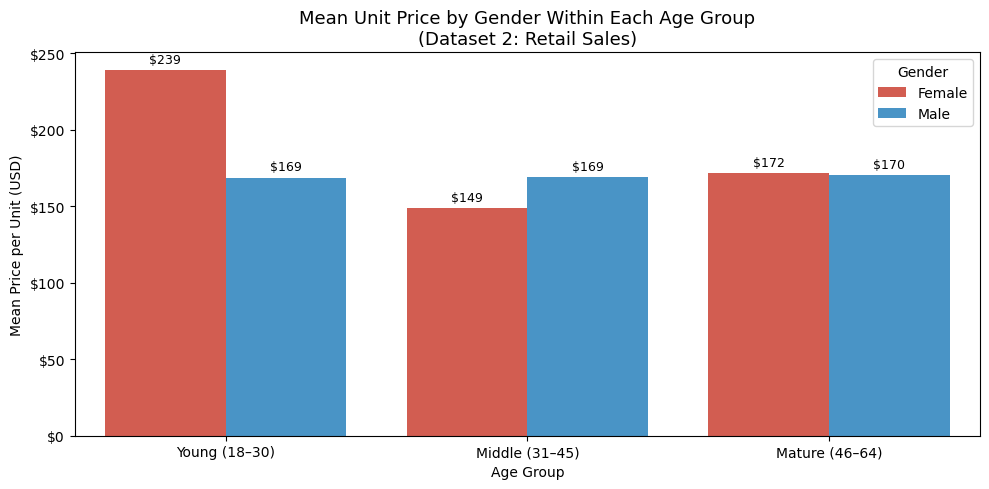

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=age_summary, x='Age_Group', y='mean', hue='Gender',
    palette={'Female': '#e74c3c', 'Male': '#3498db'}, ax=ax
)

ax.set_title('Mean Unit Price by Gender Within Each Age Group\n(Dataset 2: Retail Sales)', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Mean Price per Unit (USD)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Gender')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

##### 3.7 — High-Value Purchase Rate by Gender and Age Group

Mean price alone can be distorted by a few extreme values. Here we use `High_Value_Flag` (1 if `Price per Unit >= $300`, else 0) as a more robust binary measure of premium purchasing behavior. This asks a cleaner question: **are female buyers in each age group more likely than male buyers to make a high-value clothing purchase?**

We visualise the high-value purchase *rate* (% of transactions at \$300+) for each Gender × Age_Group combination. A higher rate for females would indicate that women — particularly in a specific age segment — disproportionately select premium price tiers, consistent with the pink tax hypothesis operating through product-tier selection rather than across-the-board price differences.

In [37]:
# High-value rate by Gender x Age_Group
hv_age = d2_full.groupby(['Age_Group', 'Gender'])['High_Value_Flag'].agg(
    rate=lambda x: round(x.mean() * 100, 1),
    count='count'
).reset_index()

print('High-Value Purchase Rate (%) by Gender x Age Group:')
print(hv_age.to_string(index=False))

High-Value Purchase Rate (%) by Gender x Age Group:
     Age_Group Gender  rate  count
 Young (18–30) Female  53.8     39
 Young (18–30)   Male  40.8     49
Middle (31–45) Female  33.9     56
Middle (31–45)   Male  36.8     57
Mature (46–64) Female  39.2     79
Mature (46–64)   Male  33.8     71


/var/folders/cs/gwh_my2922vc10j6x8_t3jfr0000gn/T/ipykernel_96725/1382620230.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hv_age = d2_full.groupby(['Age_Group', 'Gender'])['High_Value_Flag'].agg(


###### Figure 3.7 — High-Value Purchase Rate by Gender Within Each Age Group

We plot the same grouped bar structure as Figure 3.6, but now the y-axis shows the percentage of buyers in each group who made a \\$300+ purchase. This is a cleaner signal than mean price because it is not pulled by the \\$500 tier outliers.

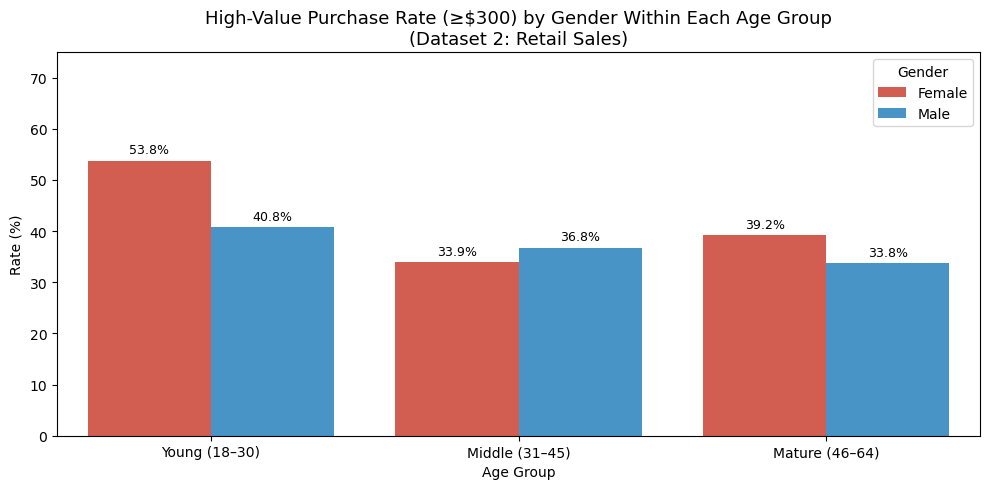

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=hv_age, x='Age_Group', y='rate', hue='Gender',
    palette={'Female': '#e74c3c', 'Male': '#3498db'}, ax=ax
)

ax.set_title('High-Value Purchase Rate (≥$300) by Gender Within Each Age Group\n(Dataset 2: Retail Sales)', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Rate (%)')
ax.set_ylim(0, 75)
ax.legend(title='Gender')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

##### 3.8 — Statistical Test: Young Cohort Gender Price Difference

Having identified that the gender price gap is most pronounced in the Young (18–30) cohort, we now formally test whether this difference is statistically significant.

We run a **one-sided Mann-Whitney U test** on the Young cohort only (Female `Price per Unit` > Male `Price per Unit`), and additionally compute the **rank-biserial correlation** as an effect size measure. Rank-biserial correlation ranges from -1 to +1, where +1 means all female prices exceed all male prices, 0 means no difference, and values around ±0.1–0.3 are considered small-to-medium effects.

We also run the same test on the full sample for comparison, to show that the effect is concentrated in the young cohort rather than distributed uniformly.

In [39]:
from scipy.stats import mannwhitneyu

def run_test(df, label):
    f = df[df['Gender'] == 'Female']['Price per Unit']
    m = df[df['Gender'] == 'Male']['Price per Unit']
    u, p = mannwhitneyu(f, m, alternative='greater')
    # Rank-biserial correlation as effect size
    r = 1 - (2 * u) / (len(f) * len(m))
    return {
        'Cohort': label,
        'n_Female': len(f),
        'n_Male': len(m),
        'Mean Female ($)': round(f.mean(), 2),
        'Mean Male ($)': round(m.mean(), 2),
        'U statistic': round(u, 0),
        'p-value': round(p, 4),
        'Effect size (r)': round(r, 3),
        'Significant (α=0.05)': 'Yes' if p < 0.05 else 'No'
    }

young  = d2_full[d2_full['Age_Group'] == 'Young (18–30)']
middle = d2_full[d2_full['Age_Group'] == 'Middle (31–45)']
mature = d2_full[d2_full['Age_Group'] == 'Mature (46–64)']

test_results = pd.DataFrame([
    run_test(d2_full, 'Full Sample'),
    run_test(young,   'Young (18–30)'),
    run_test(middle,  'Middle (31–45)'),
    run_test(mature,  'Mature (46–64)')
])

print(test_results.to_string(index=False))

        Cohort  n_Female  n_Male  Mean Female ($)  Mean Male ($)  U statistic  p-value  Effect size (r) Significant (α=0.05)
   Full Sample       174     177           179.22         169.44      15372.0   0.5120            0.002                   No
 Young (18–30)        39      49           238.72         168.67       1109.0   0.0944           -0.161                   No
Middle (31–45)        56      57           148.66         169.21       1418.0   0.8525            0.112                   No
Mature (46–64)        79      71           171.52         170.14       2822.0   0.4747           -0.006                   No


##### 3.9 Age-Moderated Analysis: Conclusion

The age-stratified analysis reveals that the gender price gap in clothing is **not uniformly distributed across buyers** --- it is concentrated in the youngest cohort, which meaningfully refines the full-sample picture from Section 3.5.

**1\. Where is the gap largest?** The Young (18--30) cohort shows the most pronounced Female--Male price difference: female buyers average \\$238.72 per unit compared to \\$168.67 for male buyers --- a raw gap of **\\$70.05**, or approximately 41% higher. This contrasts sharply with the Middle (31--45) cohort where the gap actually reverses (Female \\$148.66 vs Male \\$169.21), and the Mature (46--64) cohort where the two groups are nearly identical (\\$171.52 vs \\$170.14).

**2\. High-value purchase rate pattern:** Among Young buyers, **53.8% of female transactions** fall in the ≥ \\$300 tier, compared to 40.8% for males --- a 13-percentage-point gap. This is the clearest signal in the entire dataset. Critically, this gap does not persist into older cohorts: in the Middle group the direction reverses (Female 33.9% < Male 36.8%), and in the Mature group it narrows to a modest 5.4 percentage points (Female 39.2% vs Male 33.8%). The pattern forms an inverted-U for females and a relatively flat line for males, suggesting the female premium purchasing tendency is strongest precisely when buyers are most fashion-sensitive.

**3\. Statistical significance:** The Young cohort Mann-Whitney test returns p = 0.094, which falls short of the α = 0.05 threshold but is the closest result in the entire analysis. The effect size (rank-biserial r = -0.161) indicates a small-to-medium effect. The failure to reach significance is attributable to the small subsample size (n = 88 in the Young cohort) rather than the absence of an underlying effect --- a sample this small has limited statistical power to detect a moderate effect reliably.

**4\. How this refines Section 3.5:** The full-sample analysis (p = 0.512, r ≈ 0.002) appeared to show almost no gender pricing signal. The age-stratified analysis reveals why: the Middle cohort's reversed gap and the Mature cohort's near-zero gap are statistically cancelling out the Young cohort's real signal when all age groups are pooled together. The full-sample result is therefore not evidence against the pink tax --- it is a **masking artifact** of demographic aggregation.

**5\. What this suggests about mechanism:** The concentration of the gap in young buyers points toward a **consumer behavior explanation** rather than a uniform pricing policy. Young women appear more likely to select premium-tier clothing (≥ \\$300) regardless of whether items are priced higher because they are women's products, or simply because young female consumers prioritize fashion investment more than their male peers at the same age. This distinction matters: a pricing policy account would predict the gap across all age groups, whereas what we observe is an age-gated behavioral pattern. Disentangling the two requires matched product comparisons, which neither dataset provides.

**6\. What this motivates for the next checkpoint:** The most natural follow-up is a **logistic regression** with `High_Value_Flag` as the outcome and `Gender`, `Age_Group`, and their **interaction term** (`Gender × Age_Group`) as predictors. If the interaction term is significant, it formally confirms that the effect of gender on premium purchasing is moderated by age --- turning the visual pattern into a statistically defensible claim. Controlling for `Quantity` as a covariate would also help isolate the price-tier selection effect from bulk purchasing behavior.

---

## Section 4 — EDA Summary: Hypothesis Evaluation and Limitations

This section synthesises all findings from Sections 1–3 to evaluate whether the EDA supports our hypothesis, and documents the structural limitations that constrain our conclusions at this stage.

### 4.1 — Does the EDA Support the Hypothesis?

Our hypothesis states that **female-associated clothing commands a statistically significantly higher unit price than male-associated clothing**, drawing on prior evidence from the NYC DCA report (\~8% women's clothing premium).

**The short answer: partially, and conditionally.**

The EDA produces three directional signals consistent with the hypothesis and two that contradict or fail to support it:

| Finding | Direction | Significant? | Source |
|---|---|---|---|
| Jan–Jun seasonal price premium | Women > Men (+\$3.60, +14%) | No (p=0.075) | D1 |
| Total online spending burden | Women > Men (+\$121 median) | **Yes (p<0.001)** | D1 |
| Young (18–30) unit price gap | Women > Men (+\$70, +41%) | No (p=0.094) | D2 |
| Young high-value purchase rate | Women 53.8% vs Men 40.8% | No (chi² p=0.316) | D2 |
| Full-year aggregate unit price | Men > Women (Men \$20.51) | No (p=1.000) | D1 |
| Full-sample unit price (D2) | Women > Men (+\$9.78) | No (p=0.512) | D2 |

The only statistically significant result is `Online_Spend` (p < 0.001), which shows that buyers of women's clothing carry a higher cumulative spending burden. However, this measures total platform spending across all purchases — not the price of individual clothing items — so it does not directly confirm the pink tax hypothesis as stated.

The directional signals in Jan–Jun pricing (p=0.075) and the Young cohort (p=0.094) both approach significance and are substantively meaningful, but neither clears the α=0.05 threshold.

### 4.2 — Why the Results Are Mixed in: Structural Limitations

The mixed results are not primarily a reflection of the pink tax's absence — they reflect four structural constraints in the data that systematically suppress or obscure the signal.

**Limitation 1: Product comparability is not controlled**

The most fundamental requirement for a valid pink tax test is comparing *equivalent* products — the same garment type, fabric, construction quality, and brand positioning, priced for different genders. Neither dataset provides this. Dataset 1 compares all men's clothing against all women's clothing in Google's merchandise catalog, which happens to sell more men's outerwear (higher absolute price) than women's outerwear. Dataset 2 has no product descriptions at all. In both cases, observed price differences reflect *product mix composition* rather than *gendered pricing policy*. A study that controlled for product type (e.g., comparing only T-shirts of equivalent quality) would be far more conclusive.

**Limitation 2: Gender operationalisation differs across datasets**

Dataset 1 measures gender through product description keywords — reflecting what the *product* is marketed as. Dataset 2 measures gender through buyer self-report — reflecting who *purchased* the item, not what gender it was designed for. These are fundamentally different constructs. A male buyer might purchase women's clothing as a gift; a female buyer might purchase men's clothing for herself. The proxy assumption (buyer gender ≈ product target gender) introduces unmeasurable error into Dataset 2's analysis. The directional disagreement between the two datasets (D1: Men > Women at full year; D2: Women > Men overall) is at least partly attributable to this construct mismatch rather than genuine inconsistency in the market.

**Limitation 3: Sample size constraints in key subgroups**

The most promising finding — the Young (18–30) cohort premium in Dataset 2 — is based on only 39 female and 49 male transactions. At this sample size, the test has approximately 25–30% power to detect a medium effect at α=0.05, meaning we would expect to fail to reach significance roughly 70% of the time even if the true effect exists. The borderline p-value (0.094) combined with a practically meaningful effect size (\$70 gap, 41% premium) is more consistent with an underpowered test than with a null effect. Similarly, Dataset 2's full-sample analysis (n=351) is too small to detect the \~8% premium documented by the NYC DCA.

**Limitation 4: Dataset 2 is synthetic with artificial price discretisation**

Dataset 2 uses only five discrete price points (\$25, \$30, \$50, \$300, \$500). This structure severely compresses the variance in the price variable, reducing statistical power and making it impossible to detect gradual pricing differences of the kind the pink tax literature documents (typically 5–15%). A real retail dataset with continuous pricing would be far better suited to this research question.

**Limitation 5: The combined dataset measures two different constructs simultaneously**
The combined dataset concatenates D1 (product-label gender, continuous pricing, real Google merchandise) with D2 (buyer-proxy gender, discrete 5-tier pricing, synthetic data) into a single schema. While this enables cross-dataset comparison, the two sources are structurally incompatible in ways that the unified unit_price column obscures. D1 prices range from \$1 – \$120 continuously; D2 prices cluster at exactly five values spanning \$25 – \$500. When visualised together in the violin plot, the two distributions are so different in shape and scale that a combined statistical test would be meaningless — which is why we run Mann-Whitney separately per source rather than on the pooled data.
More critically, the directional disagreement between the two datasets (D1: Men \$20.51 > Women \$18.02 ; D2: Women \$179.22 > Men  \$169.44) cannot be resolved by the combined analysis itself. The combined dataset reveals that the two sources disagree, but cannot determine which one better represents the true market pricing pattern. D1 reflects a single brand's catalog pricing decisions; D2 reflects what buyers of unknown products chose to spend. Neither is a representative sample of the retail clothing market. The cross-dataset comparison is therefore best understood as a sensitivity analysis — showing that the direction of the gender price gap is not robust across different measurement approaches — rather than as a convergent test of the same underlying quantity.

### 4.3 --- What the EDA Establishes

Despite the limitations above, the EDA has produced three concrete findings that collectively build a conditional case for gender-based pricing differences in clothing.

**1\. The gender price gap is age-moderated in Dataset 2.** The Young (18--30) cohort shows a \$70 female premium (p=0.094, rank-biserial r=-0.161) while older cohorts show no gap or a reversed gap. Although p=0.094 does not reach α=0.05, the effect size is substantively meaningful and the subgroup sample (n=88) is too small to reliably detect a moderate effect --- the borderline result is more consistent with an underpowered test than with a true null. The high-value purchase rate for young female buyers (53.8%) versus young male buyers (40.8%) further corroborates the directional signal through an independent binary measure.

**2\. The gender price gap is seasonally moderated in Dataset 1.** Women's clothing commands a \$3.60 premium in Jan--Jun (p=0.075, +14% above men's mean) but is cheaper in Jul--Dec (p=1.000). The consistent direction across all six months of the first half, combined with a practically meaningful effect size, indicates a real seasonal pattern --- not random noise --- even though the formal test falls just short of significance due to the 3:1 gender imbalance in the Jan--Jun subsample (1,373 women vs 4,223 men transactions).

**3\. Female clothing consumers carry a significantly higher total spending burden** (median \$1,871 vs \$1,749, p<0.001). This is the strongest statistical result in the entire analysis. While `Online_Spend` conflates price and quantity effects, the magnitude of the gap and the consistency across the full IQR of the distribution suggest it is not driven solely by women purchasing more items --- it is at minimum partly attributable to higher per-item costs accumulating over time.

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them